In [1]:
atomstring = '''
Fe -0.64147387529051 0.51990405379180 0.11450483185168
O 0.33915564253394 2.18819453520299 -0.84159903476570
H 0.65823736209818 2.99799985286513 -0.40575899522591
O -1.29914529040912 -0.20924466129350 -1.80322550106302
H -2.11419692217693 0.03267722517314 -2.27701147100162
O 0.01237770373627 1.24396717111997 2.03533113813669
H 0.83097217272839 1.00756306178418 2.50577204385612
O -1.62284672685044 -1.15048542622041 1.07007991103536
H -1.94592790838151 -1.95766677806096 0.63237073377438
O -2.41866907277644 1.66373032346654 0.25658821238371
H -2.55381601393967 2.56024091790599 -0.09930153080408
O 1.13404022498401 -0.62623224778001 -0.02436092147139
H 1.26370551457750 -1.52400168391753 0.33034524187694
H -3.28110369794222 1.35873477131317 0.59094893393907
H -0.81032015579443 -0.82248643308581 -2.37966496653734
H 1.99795010138314 -0.32692539271158 -0.36001715946551
H 0.57998322602479 2.26642229799559 -1.78148703231078
H -0.47668197075682 1.85673194452426 2.61208351578631
H -1.85653031374812 -1.23356353207299 2.011352050005
'''

In [2]:
import numpy as np
from pyscf import gto, scf, mp, cc

mol = gto.M(atom = atomstring,
            basis = {
                'default': 'ccpvdz-dk',
                'Fe': 'ccpwcvtz-dk'
                },
            verbose = 4,
            unit = 'angstrom',
            symmetry = 0,
            charge = 2,
            spin = 4,
            max_memory = 20000,
            )

mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk('./hs_tdz_mf.chk')
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

# stable = False
# for i in range(10):
#     print(f'mf stability test {i+1}')
#     if not stable:
#         mo_i, _, stable,_ = mf.stability(return_status=True)
#         dm = mf.make_rdm1(mo_i,mf.mo_occ)
#         mf = mf.newton()
#         mf.kernel(dm0=dm)
#     elif stable:
#         print(f'mf energy: {mf.e_tot}, stability {stable}')
#         break

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-29-generic', version='#29~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Wed Aug 12 17:25:56 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sat Aug 22 13:55:35 2026
PySCF version 2.14.0
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD      c63a953ba603a5ad8c1d65d88da72aaf05ede4d8

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit   

np.float64(-1727.5438115926102)

In [9]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (235, 235)
frozen orbitals 11
max_memory 20000 MB (current use 3261 MB)
E(DFUMP2) = -1729.38153669198  E_corr = -1.8377250993683
E(SCS-DFUMP2) = -1729.29866110431  E_corr = -1.75484951169575
E_corr(same-spin) = -0.519716085630241
E_corr(oppo-spin) = -1.31800901373806
-1.8377250993682965


In [3]:
options = {
           'eql_time': 40,
           'n_blocks': 50,
           'n_walkers': 100,
           'mix_precision': True,
           'max_memory': 300000,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

from afqmc.lno_afqmc import tools, lno_afqmc_test
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        save2=None,
        read_from=None,
        )


Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.006798560655  |g|= 0.0421664
macro= 1  f(x)= 55.011902632282  delta_f= 0.00510407  |g|= 0.0199265  5 KF 27 Hx
macro= 2  f(x)= 55.013323663681  delta_f= 0.00142103  |g|= 0.00511249  5 KF 30 Hx
macro= 3  f(x)= 55.013391340588  delta_f= 6.76769e-05  |g|= 0.00106101  2 KF 10 Hx
macro= 4  f(x)= 55.013399281313  delta_f= 7.94073e-06  |g|= 0.00210416  1 KF 4 Hx
macro= 5  

In [4]:
threshs = [1e-4, 3e-5, 1e-5, 3e-6, 1e-6]
emp1 = np.zeros(len(threshs))
size1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    lno_thresh = [lno_thresh, lno_thresh]
    emp1[i], _, _, _, size1[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )




 ******* LNO-CALCULATION ******* 

LNO THRESHOLD = [0.0001, 0.0001]
LNO freezes at least the chemcore orbitals for each element!
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
Run Fragment range(0, 7)

CPU/GPU pipeline: ON (prefetch depth 1)
  the LNO-MP2/CCSD of the next fragment(s) run on the CPU while the current fragment's AFQMC occupies the GPU


========================== LNO-FRAGMENT [Fe0] 1/(7,7) ==========================
Fragment Num.  1
Fragment Idx.  1
Fragment Name  Fe0
LNO THRESHOLD  [0.0001, 0.0001]
PySCF Threads  16
LNO-LAS: 
Spin channel 0: 27/44 Occ | 49/202 Vir | 76/246 MOs

Spin channel 1: 24/40 Occ | 48/206 Vir | 72/246 MOs

LNO-MP2 Fragment Energy:  -0.53174686
LNO-CCSD Fragment Energy: 0.00000000
LNO-CPU time (s):         3.01 (LAS 0.95 | MP2 2.06 | CCSD 0.00)
LNO-CPU wait time (s):    3.01 (0.1% hidden)


======================== LNO-FRAGMENT [O1H2H16] 2/(7,7) ========================
Fragment Num.  2
Fragment Idx. 

In [5]:
emp2 = np.zeros(len(threshs))
size2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):

    emp2[i], _, _, _, size2[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )


 ******* LNO-CALCULATION ******* 

LNO THRESHOLD = 0.0001
LNO freezes at least the chemcore orbitals for each element!
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
Run Fragment range(0, 7)

CPU/GPU pipeline: ON (prefetch depth 1)
  the LNO-MP2/CCSD of the next fragment(s) run on the CPU while the current fragment's AFQMC occupies the GPU


========================== LNO-FRAGMENT [Fe0] 1/(7,7) ==========================
Fragment Num.  1
Fragment Idx.  1
Fragment Name  Fe0
LNO THRESHOLD  [0.001, 0.0001]
PySCF Threads  16
LNO-LAS: 
Spin channel 0: 13/44 Occ | 49/202 Vir | 62/246 MOs

Spin channel 1: 13/40 Occ | 48/206 Vir | 61/246 MOs

LNO-MP2 Fragment Energy:  -0.52897261
LNO-CCSD Fragment Energy: 0.00000000
LNO-CPU time (s):         3.04 (LAS 0.97 | MP2 2.07 | CCSD 0.00)
LNO-CPU wait time (s):    3.04 (0.1% hidden)


======================== LNO-FRAGMENT [O1H2H16] 2/(7,7) ========================
Fragment Num.  2
Fragment Idx.  2
Fragment

[ 76. 120. 146. 165. 176.]
[-1.77167762 -1.8125342  -1.82735581 -1.83380529 -1.83557197]
[ 62. 102. 140. 165. 176.]
[-1.76310149 -1.79960817 -1.82277248 -1.83236495 -1.83527083]


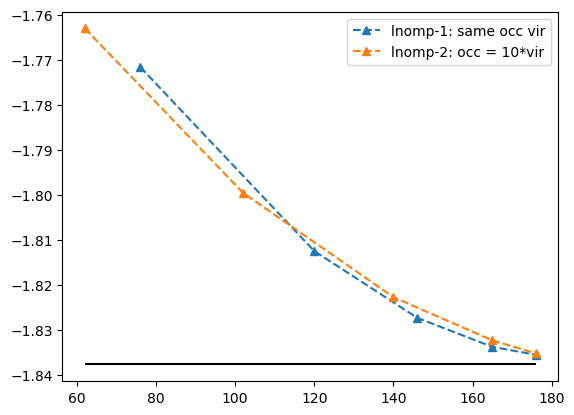

In [13]:
print(size1)
print(emp1)
print(size2)
print(emp2)
from matplotlib import pyplot as plt
plt.plot(size1, emp1, "^--", color="C0", label="lnomp-1: same occ vir")
plt.plot(size2, emp2, "^--", color="C1", label="lnomp-2: occ = 10*vir")
plt.hlines(mymp.e_corr, xmin=min(np.hstack((size1,size2))), xmax=max(np.hstack((size1,size2))), colors='k')
plt.legend()
plt.show()